# 엔진 상부 T(z,t) — 한 방향 공간평균 연직 프로파일
메인엔진 footprint x=[3.5,10], y=[5.2,9], z=[0,2] (상판 2.0, 천장 3.0).
- **x-slice (PBX=6.75, YZ면)**: 각 z에서 y∈[5.2,9.0] 공간평균 → T̄(z,t)
- **y-slice (PBY=7.1, XZ면)**: 각 z에서 x∈[3.5,10.0] 공간평균 → T̄(z,t)
엔진 상판 아래(z<2)는 고체라 NaN → `np.nanmean` 으로 무시. 기존 슬라이스만 사용(재실행 불필요).

In [10]:
import warnings; warnings.filterwarnings('ignore')
import logging; logging.disable(logging.CRITICAL)
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, fdsreader
%matplotlib inline
plt.rcParams.update({'axes.labelsize':13,'axes.titlesize':13,
                     'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':10})
print('fdsreader', fdsreader.__version__)

fdsreader 1.11.7


In [11]:
RES = Path('/shared/home/wel1come1234/workspace/FDS/Engineroom/Results')
OUT = Path('/shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/engine_tz_slice')
OUT.mkdir(parents=True, exist_ok=True)

# 엔진 footprint / 슬라이스 위치 / z 범위(상판~천장) / 정상상태 창
ENG_X = (3.5, 10.0)     # 메인엔진 x 범위 (y-slice 에서 x평균 구간)
ENG_Y = (5.2, 9.0)      # 메인엔진 y 범위 (x-slice 에서 y평균 구간)
PBX_X = 6.75            # x-slice(YZ) 위치 = 엔진 중심 x
PBY_Y = 7.1             # y-slice(XZ) 위치 = 엔진 중심 y
Z_LO, Z_HI = 2.0, 3.0   # 엔진 상판 → 천장
WIN = (240.0, 300.0)    # 정상상태 평균 창 (T_END=300)

# 비교할 케이스 (완주한 fire1 vent-sweep)
CASES = {
    'fire1_p10_v20_M5': ('vent @20 s', '#2980b9'),
    'fire1_p10_v30_M5': ('vent @30 s', '#27ae60'),
    'fire1_p10_v40_M5': ('vent @40 s', '#e67e22'),
}

In [12]:
def profile_over_time(sim, orientation, target, avg_lo, avg_hi):
    """슬라이스에서 면내 한 방향(y 또는 x)을 [avg_lo,avg_hi]로 nanmean 하여
    각 z별 시간열을 만든다. 반환: z(엔진상판~천장), t, T[z,t].
    orientation 1(PBX,YZ)=축(t,y,z) → y평균 / 2(PBY,XZ)=축(t,x,z) → x평균."""
    cand = [s for s in sim.slices
            if s.orientation == orientation and 'TEMP' in s.quantity.name.upper()]
    key = (lambda s: abs(s.extent.x_start-target)) if orientation==1 \
          else (lambda s: abs(s.extent.y_start-target))
    sl = min(cand, key=key); e = sl.extent
    D = sl.to_global(masked=True, fill=np.nan)      # (t, a, z), a=y(ori1)/x(ori2)
    t = np.asarray(sl.times)
    a0, a1 = (e.y_start, e.y_end) if orientation==1 else (e.x_start, e.x_end)
    a = np.linspace(a0, a1, D.shape[1])
    z = np.linspace(e.z_start, e.z_end, D.shape[2])
    ma = (a >= avg_lo) & (a <= avg_hi)              # 엔진 footprint 구간만
    Tza = np.nanmean(D[:, ma, :], axis=1)          # (t, z)  ← nanmean 이 핵심(벽 NaN 무시)
    zs = (z >= Z_LO) & (z <= Z_HI)                 # 엔진 상판~천장만
    return z[zs], t, Tza[:, zs].T                  # (z, t)

def zplane_avg(sim, zt, fix_dir, fix_val, avg_lo, avg_hi):
    """PBZ(수평, ori 3) 슬라이스 z≈zt 에서 fix_dir 방향은 fix_val 로 고정,
    나머지 방향을 [avg_lo,avg_hi]로 nanmean → z=zt 한 지점의 시간열 T(t).
    엔진 상판(z=2.0)처럼 세로 슬라이스 격자에 없는 높이의 값을 얻는 데 사용."""
    cand = [s for s in sim.slices
            if s.orientation == 3 and 'TEMP' in s.quantity.name.upper()]
    sl = min(cand, key=lambda s: abs(s.extent.z_start - zt)); e = sl.extent
    D = sl.to_global(masked=True, fill=np.nan)      # (t, x, y)
    x = np.linspace(e.x_start, e.x_end, D.shape[1])
    y = np.linspace(e.y_start, e.y_end, D.shape[2])
    if fix_dir == 'x':                              # x-slice 패널: x고정, y평균
        i = int(np.argmin(np.abs(x - fix_val))); m = (y >= avg_lo) & (y <= avg_hi)
        return np.nanmean(D[:, i, m], axis=1)
    else:                                           # y-slice 패널: y고정, x평균
        i = int(np.argmin(np.abs(y - fix_val))); m = (x >= avg_lo) & (x <= avg_hi)
        return np.nanmean(D[:, m, i], axis=1)

def get_both(case):
    sim = fdsreader.Simulation(str(RES/case))
    zx, t, Tx = profile_over_time(sim, 1, PBX_X, *ENG_Y)  # x-slice: y-avg
    zy, _, Ty = profile_over_time(sim, 2, PBY_Y, *ENG_X)  # y-slice: x-avg
    # z=2.0 (engine top): 세로격자에 없으므로 PBZ=2.0 상판면 평균을 각 패널에 prepend
    T2x = zplane_avg(sim, Z_LO, 'x', PBX_X, *ENG_Y)
    T2y = zplane_avg(sim, Z_LO, 'y', PBY_Y, *ENG_X)
    z  = np.concatenate([[Z_LO], zx])
    Tx = np.vstack([T2x[None, :], Tx])
    Ty = np.vstack([T2y[None, :], Ty])
    return dict(z=z, t=t, Tx=Tx, Ty=Ty)

data = {c: get_both(c) for c in CASES}
for c,d in data.items():
    print(f"{c}: z={d['z'][0]:.2f}~{d['z'][-1]:.2f}({len(d['z'])}pt), "
          f"t={d['t'][0]:.0f}~{d['t'][-1]:.0f}s({len(d['t'])}frames)")

fire1_p10_v20_M5: z=2.00~3.00(15pt), t=0~300s(151frames)
fire1_p10_v30_M5: z=2.00~3.00(15pt), t=0~300s(151frames)
fire1_p10_v40_M5: z=2.00~3.00(15pt), t=0~300s(151frames)


## 1) Time-z heatmap (color=T) — per case: x-slice(y-avg) / y-slice(x-avg)

-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/engine_tz_slice/engine_Tz_time_heatmap.png


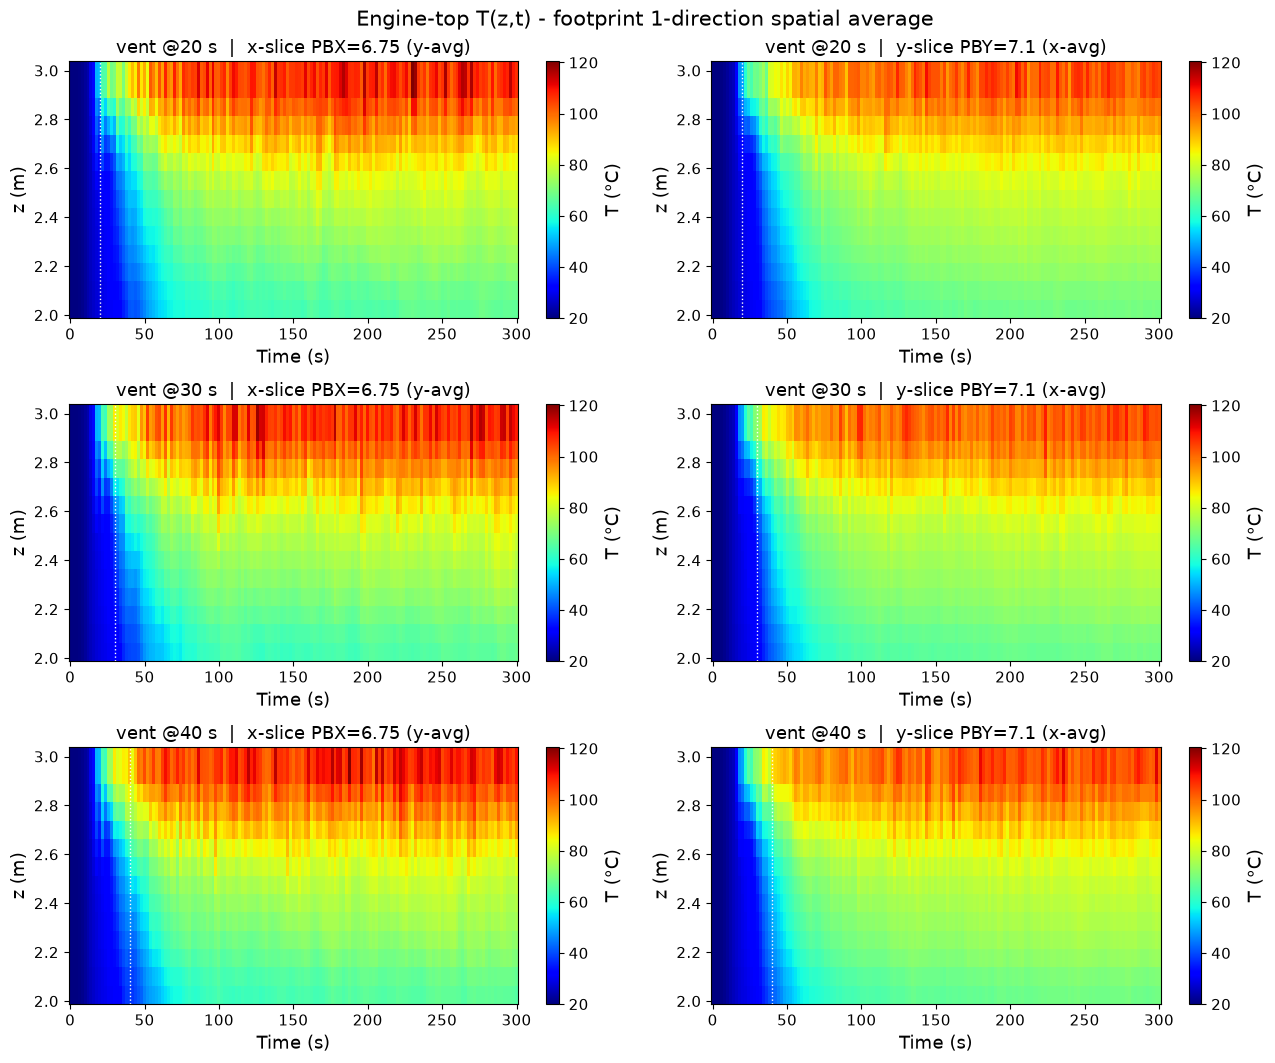

In [13]:
ncase=len(CASES)
fig,axs=plt.subplots(ncase,2,figsize=(13,3.6*ncase),squeeze=False)
vmin=min(min(np.nanmin(d['Tx']),np.nanmin(d['Ty'])) for d in data.values())
vmax=max(max(np.nanmax(d['Tx']),np.nanmax(d['Ty'])) for d in data.values())
for r,(c,(lbl,_)) in enumerate(CASES.items()):
    d=data[c]
    for col,(T,ttl) in enumerate([(d['Tx'],'x-slice PBX=6.75 (y-avg)'),
                                   (d['Ty'],'y-slice PBY=7.1 (x-avg)')]):
        ax=axs[r][col]
        pc=ax.pcolormesh(d['t'], d['z'], T, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
        ax.axvline(int(c.split('_v')[1].split('_')[0]), color='w', ls=':', lw=1)  # 환기시작
        ax.set_xlabel('Time (s)'); ax.set_ylabel('z (m)')
        ax.set_title(f'{lbl}  |  {ttl}')
        fig.colorbar(pc, ax=ax, label='T (°C)')
fig.suptitle('Engine-top T(z,t) - footprint 1-direction spatial average', fontsize=15)
fig.tight_layout()
fig.savefig(OUT/'engine_Tz_time_heatmap.png', dpi=150)
print('->', OUT/'engine_Tz_time_heatmap.png'); plt.show()

## 2) Steady-state (240-300 s avg) vertical profile comparison + reference

-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/engine_tz_slice/engine_Tz_steady_profile.png


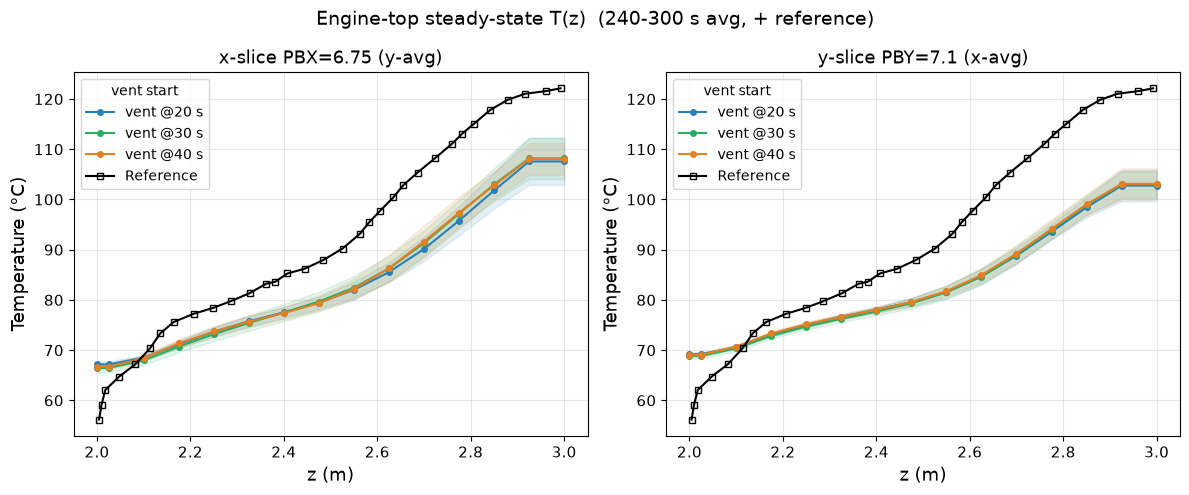

In [14]:
# --- steady-state (WIN avg) vertical profiles + reference overlay ---
ref = None
p = Path('/shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/engine_ref.csv')
if p.exists():
    ref = np.loadtxt(p, delimiter=',')   # columns = (T, z)
fig,axs=plt.subplots(1,2,figsize=(12,5))
for key,ttl,ax in [('Tx','x-slice PBX=6.75 (y-avg)',axs[0]),
                    ('Ty','y-slice PBY=7.1 (x-avg)',axs[1])]:
    for c,(lbl,col) in CASES.items():
        d=data[c]; w=(d['t']>=WIN[0])&(d['t']<=WIN[1])
        Tavg=np.nanmean(d[key][:,w],axis=1); Tstd=np.nanstd(d[key][:,w],axis=1)
        ax.plot(d['z'],Tavg,'-o',color=col,ms=4,label=lbl)
        ax.fill_between(d['z'],Tavg-Tstd,Tavg+Tstd,color=col,alpha=0.12)
    if ref is not None:                     # reference: engine_ref.csv = (T, z)
        ax.plot(ref[:,1], ref[:,0], 'k-s', lw=1.5, ms=4, mfc='none',
                label='Reference', zorder=5)
    ax.set_xlabel('z (m)'); ax.set_ylabel('Temperature (\u00b0C)')
    ax.set_title(ttl); ax.grid(alpha=0.3); ax.legend(title='vent start')
fig.suptitle(f'Engine-top steady-state T(z)  ({WIN[0]:.0f}-{WIN[1]:.0f} s avg, + reference)', fontsize=14)
fig.tight_layout()
fig.savefig(OUT/'engine_Tz_steady_profile.png', dpi=150)
print('->', OUT/'engine_Tz_steady_profile.png'); plt.show()